# Comparing optimal paths between mazes (barrier change sessions)

For a barrier change session, we're often interested in the rat's choice between the previously-optimal path on the old maze and the now-optimal path on the new maze.

We have a couple of functions to identify hexes on the divergence/convergence hexes between old and optimal paths, as well as the hexes before path divergence and hexes unique to the old/new paths.

Maze 1: frozenset({np.int64(34), np.int64(37), np.int64(10), np.int64(45), np.int64(14), np.int64(15), np.int64(24), np.int64(25), np.int64(27)})
Maze 2: frozenset({34, 37, 39, 10, 45, 14, 15, 25, 27})

Port 1 to Port 2:
Old paths: [[1, 4, 5, 7, 9, 12, 16, 13, 17, 21, 26, 31, 36, 41, 46, 42, 47, 49, 2]]
New paths: [[1, 4, 5, 7, 9, 12, 16, 13, 17, 21, 26, 31, 36, 41, 46, 42, 47, 49, 2], [1, 4, 5, 7, 9, 12, 16, 20, 24, 29, 35, 30, 36, 41, 46, 42, 47, 49, 2]]
Paths diverge at hex None, converge at hex None
Unique hexes on old path: set()
Unique hexes on new path: set()

Port 1 to Port 3:
Old paths: [[1, 4, 5, 7, 9, 12, 16, 13, 17, 21, 26, 31, 36, 30, 35, 40, 44, 39, 43, 48, 3]]
New paths: [[1, 4, 5, 7, 9, 12, 16, 20, 24, 19, 23, 28, 33, 48, 3]]
Paths diverge at hex 16, converge at hex 48
Unique hexes on old path: {35, 36, 39, 40, 43, 44, 13, 17, 21, 26, 30, 31}
Unique hexes on new path: {33, 19, 20, 23, 24, 28}

Port 2 to Port 3:
Old paths: [[2, 49, 47, 42, 46, 41, 36, 30, 35, 40, 44, 39,

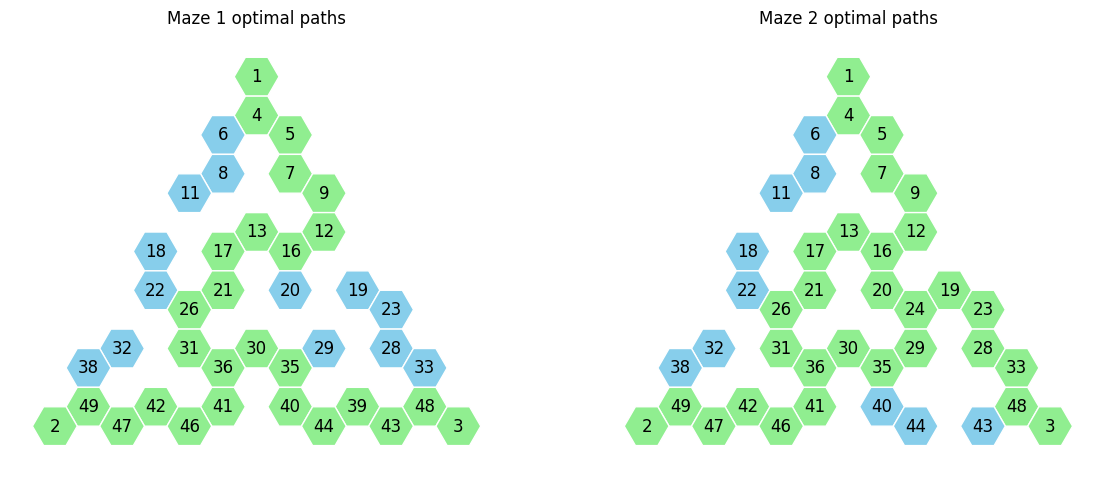

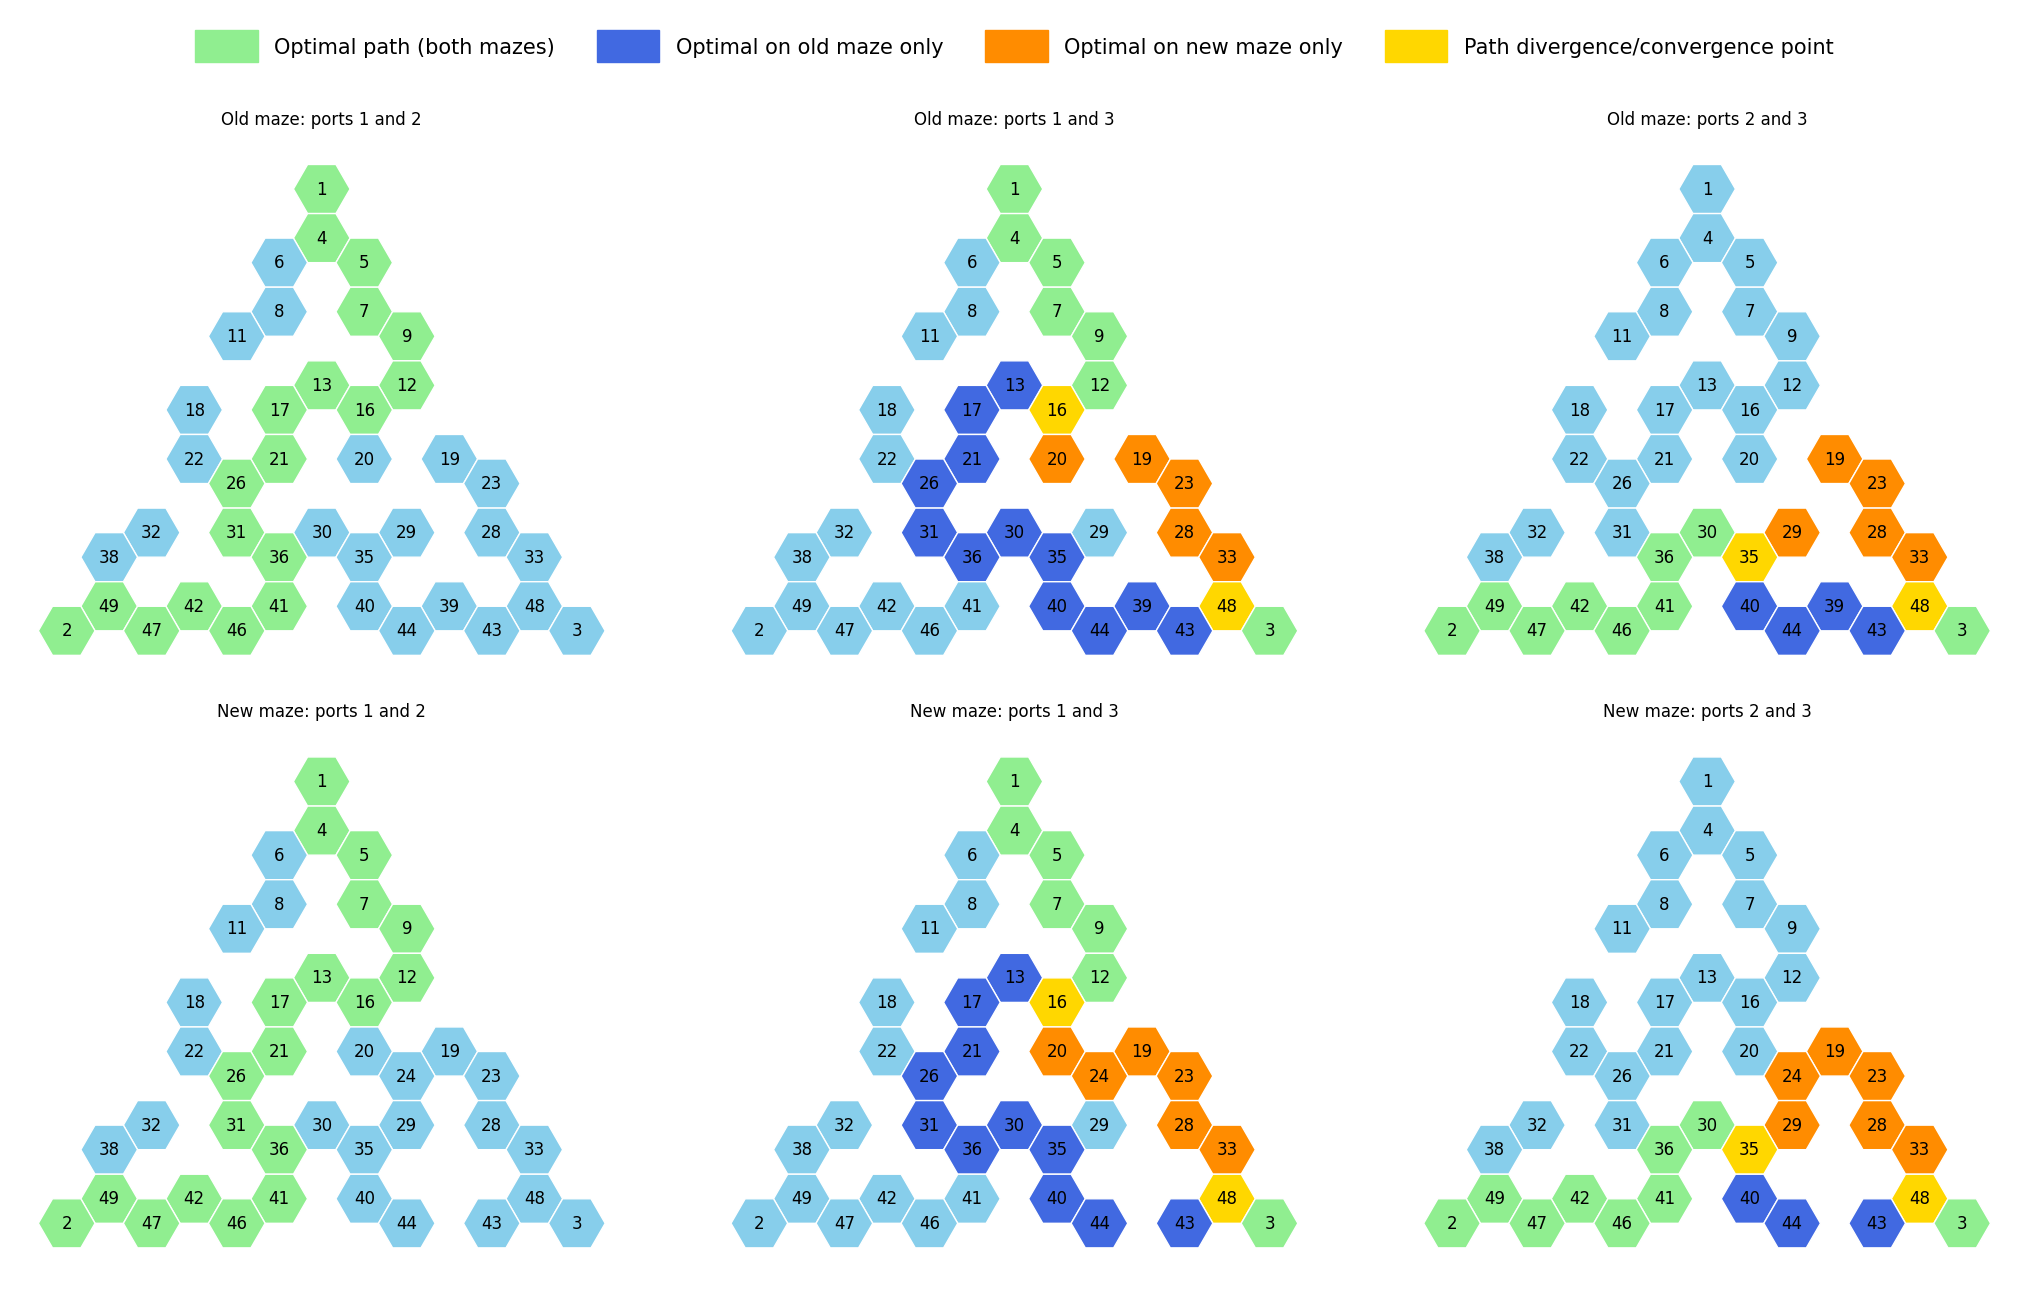

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import sys
sys.path.append("..") # Use sys to add the parent directory (where src/hexmaze lives) to the path

from src.hexmaze import (
    plot_hex_maze,
    get_old_and_new_paths,
    get_path_divergence_point,
    get_path_convergence_point,
    get_hexes_after_divergence,
    get_optimal_paths,
)

# Load the barrier sequence database and grab 2 mazes that differ by one barrier
barrier_sequence_database = pd.read_pickle('../Barrier_Sequence_Databases/barrier_sequence_database.pkl')
sequence = barrier_sequence_database.iloc[4]['barrier_sequence']
maze_1, maze_2 = sequence[0], sequence[1]

# Plot the 2 mazes with optimal paths shown
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].set_title("Maze 1 optimal paths")
print(f"Maze 1: {maze_1}")
plot_hex_maze(maze_1, ax=axes[0], show_barriers=False, show_optimal_paths=True)
axes[1].set_title("Maze 2 optimal paths")
plot_hex_maze(maze_2, ax=axes[1], show_barriers=False, show_optimal_paths=True)
print(f"Maze 2: {maze_2}")

# Compare old vs new optimal paths for each port pair
fig, axes = plt.subplots(2, 3, figsize=(21, 12))

for i, (start, end) in enumerate([(1, 2), (1, 3), (2, 3)]):
    # Get the hex where optimal paths between these ports diverge
    divergence_point = get_path_divergence_point(maze_1, maze_2, start, end)
    # Get the hex where optimal paths between these ports converge (aka divergence point if port order was switched)
    convergence_point = get_path_convergence_point(maze_1, maze_2, start, end)
    # Get the old and new optimal paths between ports
    old_paths, new_paths = get_old_and_new_paths(maze_1, maze_2, start, end)
    # Get hexes unique to the old and new path between ports (between divergence/convergence)
    hexes_on_old_path, hexes_on_new_path = get_hexes_after_divergence(maze_1, maze_2, start, end)
    print(f"\nPort {start} to Port {end}:")
    print(f"Old paths: {old_paths}")
    print(f"New paths: {new_paths}")
    print(f"Paths diverge at hex {divergence_point}, converge at hex {convergence_point}")
    print(f"Unique hexes on old path: {hexes_on_old_path}")
    print(f"Unique hexes on new path: {hexes_on_new_path}")
    
    # Highlight optimal paths between ports in light green
    # (because differing hexes on optimal paths will be overridden by subsequent highlights,
    # we can use get_optimal_paths for maze_1 and use it for both maze 1 and 2)
    optimal_paths = get_optimal_paths(maze_1, start, end)
    optimal_path_hexes = {hex for path in optimal_paths for hex in path}

    # Highlight old path hexes in blue, new path hexes in orange, 
    # and path divergence/convergence points in gold
    path_choice_points = set()
    if divergence_point is not None:
        path_choice_points.add(divergence_point)
    if convergence_point is not None:
        path_choice_points.add(convergence_point)

    highlight = [optimal_path_hexes, hexes_on_old_path, hexes_on_new_path, path_choice_points]
    colors = ["lightgreen", "royalblue", "darkorange", "gold"]

    # Plot the path difference on the old maze
    plot_hex_maze(maze_1, ax=axes[0, i], highlight_hexes=highlight, highlight_colors=colors, show_barriers=False)
    axes[0, i].set_title(f"Old maze: ports {start} and {end}")

    # Plot the path difference on the new maze
    plot_hex_maze(maze_2, ax=axes[1, i], highlight_hexes=highlight, highlight_colors=colors, show_barriers=False)
    axes[1, i].set_title(f"New maze: ports {start} and {end}")

# Define legend handles
legend_handles = [
    mpatches.Patch(color="lightgreen", label="Optimal path (both mazes)"),
    mpatches.Patch(color="royalblue", label="Optimal on old maze only"),
    mpatches.Patch(color="darkorange", label="Optimal on new maze only"),
    mpatches.Patch(color="gold", label="Path divergence/convergence point"),
]

# Add a single shared legend outside the plots
fig.legend(handles=legend_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08), fontsize=15,
    handlelength=3, handleheight=2, borderpad=1, frameon=False,)

plt.tight_layout()
plt.show()
